In [5]:
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv("powerplant_data.csv")

In [9]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [11]:
# AT => temperature 
# V => Vaccum
# AP => Pressure
# RH => humidity

# PE => Produced energy

In [13]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [15]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [17]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [19]:
# Split out data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state =42
)

In [20]:
df.shape

(9568, 5)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [22]:
X_test_scaled

array([[ 1.36255441,  0.24305848, -1.27798491, -1.04586379],
       [ 0.82147733,  1.36986442, -0.74695303,  0.31071896],
       [-0.247116  , -0.73708132,  1.92304887, -0.14668594],
       ...,
       [-0.67970645, -1.15815506, -0.31652036, -0.05697206],
       [ 1.33136451,  1.34463153, -0.87558808, -0.39000089],
       [-0.26474508, -0.26711887,  0.33984824,  1.14397069]])

In [23]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [26]:
type(X_train_scaled)

numpy.ndarray

In [31]:
type(y_train)
y_train.shape

(7654,)

In [32]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [35]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# Deep Learning

In [53]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6,1),
        )


    def forward(self, x):
        return self.model(x)

In [55]:
import torch.optim as optim
model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [57]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb)  #forwrad prop...... predicted outputs for this batch
        loss = crietrion(outputs, yb)  # compute loss
        loss.backward()  # back prop.... compute gradients 
        optimizer.step()  # params update 

        running_loss += loss.item()  # loss is a tensor => py float 

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():  # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = ${epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")  # .pt or .pth

epoch 1/100 ==> train loss = $206015.86907552084 & val loss = 204554.546875
epoch 2/100 ==> train loss = $199754.0556640625 & val loss = 190605.703125
epoch 3/100 ==> train loss = $169157.6970703125 & val loss = 141181.71875
epoch 4/100 ==> train loss = $107222.2390625 & val loss = 74579.8828125
epoch 5/100 ==> train loss = $50510.16920166016 & val loss = 33290.703125
epoch 6/100 ==> train loss = $25730.172998046874 & val loss = 21177.01171875
epoch 7/100 ==> train loss = $18970.199666341145 & val loss = 16951.63671875
epoch 8/100 ==> train loss = $15394.412821451822 & val loss = 13609.724609375
epoch 9/100 ==> train loss = $12170.943119303385 & val loss = 10496.9541015625
epoch 10/100 ==> train loss = $9177.961254882812 & val loss = 7713.76611328125
epoch 11/100 ==> train loss = $6551.022520955404 & val loss = 5321.74072265625
epoch 12/100 ==> train loss = $4368.064860026042 & val loss = 3466.582275390625
epoch 13/100 ==> train loss = $2799.75921198527 & val loss = 2204.9169921875
epo

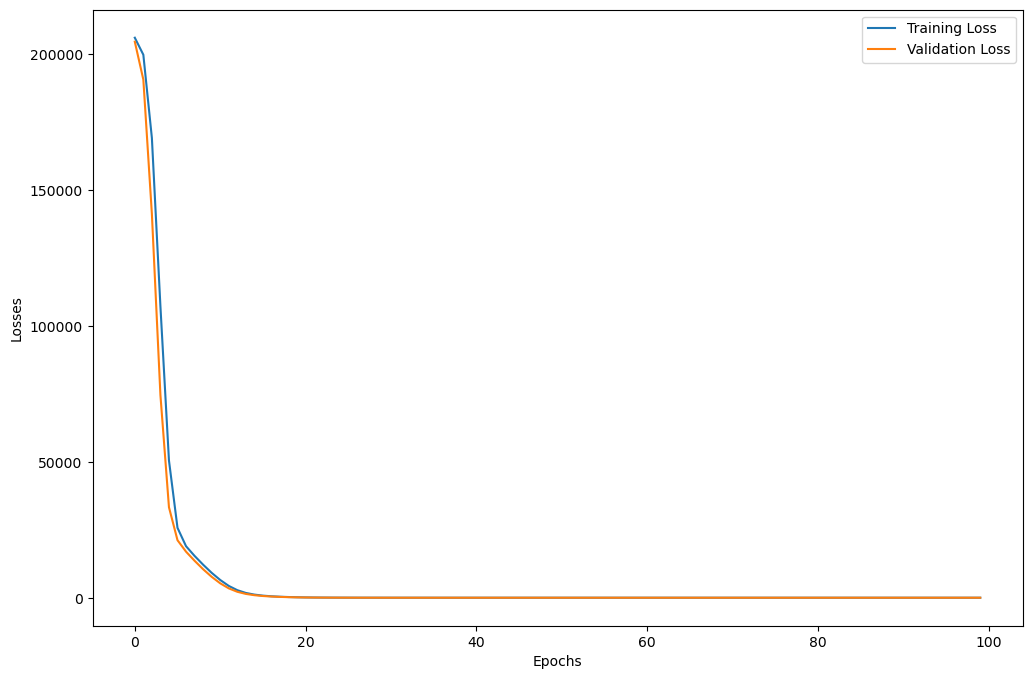

In [58]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize=(12,8))
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [59]:
# Loading the bst model 
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [65]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.38924217224121
Testing MSE: 18.712594985961914


In [69]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9346043122134131


In [71]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,434.766235,433.27
1,436.704620,438.16
2,461.615967,458.42
3,476.827087,480.82
4,435.136871,441.41
...,...,...
1909,451.236084,456.70
1910,431.247620,438.04
1911,467.519348,467.80
1912,430.717133,437.14
